In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('economic_index.csv')

In [3]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [6]:
#Drop the unnecessary columns 

df.drop(columns=['year','month','Unnamed: 0'], inplace=True)

In [7]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


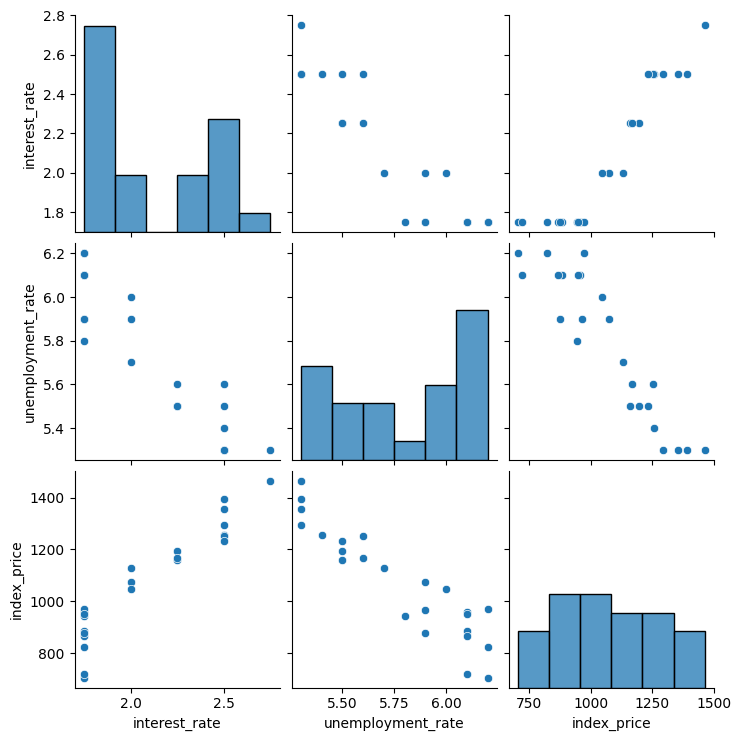

In [8]:
import seaborn as sns 
sns.pairplot(df)

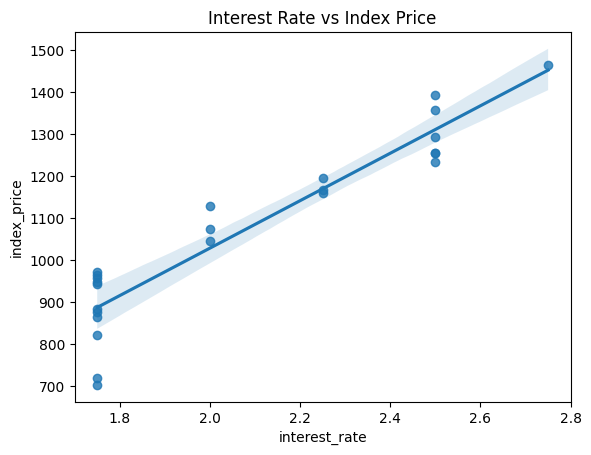

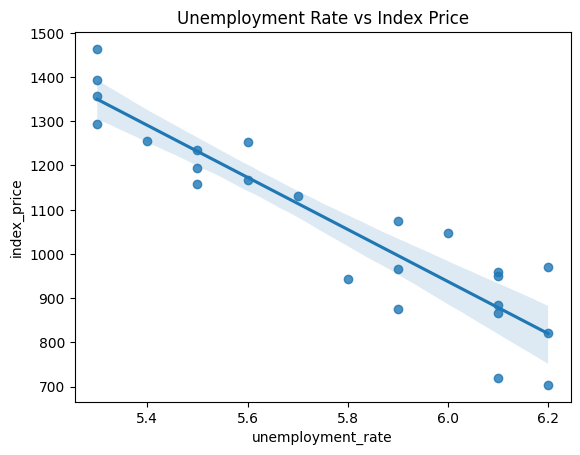

In [9]:
# Relationship: interest_rate vs index_price
sns.regplot(x='interest_rate', y='index_price', data=df)
plt.title('Interest Rate vs Index Price')
plt.show()

# Relationship: unemployment_rate vs index_price
sns.regplot(x='unemployment_rate', y='index_price', data=df)
plt.title('Unemployment Rate vs Index Price')
plt.show()

In [12]:
#Independent and dependent columns 

X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [13]:
X,y

(    interest_rate  unemployment_rate
 0            2.75                5.3
 1            2.50                5.3
 2            2.50                5.3
 3            2.50                5.3
 4            2.50                5.4
 5            2.50                5.6
 6            2.50                5.5
 7            2.25                5.5
 8            2.25                5.5
 9            2.25                5.6
 10           2.00                5.7
 11           2.00                5.9
 12           2.00                6.0
 13           1.75                5.9
 14           1.75                5.8
 15           1.75                6.1
 16           1.75                6.2
 17           1.75                6.1
 18           1.75                6.1
 19           1.75                6.1
 20           1.75                5.9
 21           1.75                6.2
 22           1.75                6.2
 23           1.75                6.1,
 0     1464
 1     1394
 2     1357
 3     1293
 

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.25,random_state=43)

In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [16]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()

In [18]:
regressor.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
from sklearn.model_selection import cross_val_score

In [20]:
validationscore= cross_val_score(regressor,X_train,Y_train,scoring='r2',cv=3)

In [21]:
np.mean(validationscore)

np.float64(0.8885897322650029)

In [24]:
Y_pred=regressor.predict(X_test)

In [25]:
regressor.coef_

array([156.27672775, -49.75730695])

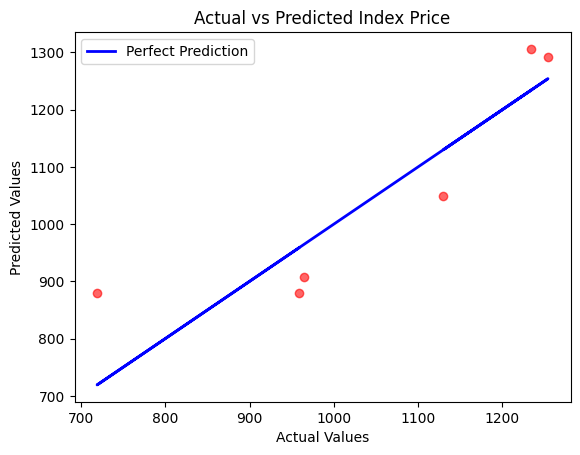

In [28]:
# Scatter plot: Actual vs Predicted
plt.scatter(Y_test, Y_pred, color='red', alpha=0.6)
plt.plot(Y_test, Y_test, color='blue', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Index Price')
plt.legend()
plt.show()

In [29]:
# Model Evaluation Metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2 = r2_score(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
mae = mean_absolute_error(Y_test, Y_pred)

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"\nCross-Validation R² Score: {np.mean(validationscore):.4f}")

R² Score: 0.7673
RMSE: 89.5658
MAE: 81.0521

Cross-Validation R² Score: 0.8886


In [30]:
new_data = np.array([[2.5, 5.5]])
new_data_scaled = scaler.transform(new_data)

d:\Learnings\DataScienceLearning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [31]:
regressor.predict(new_data)

array([1196.02663113])

In [32]:
regressor.predict(new_data_scaled)

array([1305.99448602])